# Random Forest Baseline – Uttarakhand Forest Fire Prediction

This notebook develops a static spatial Random Forest baseline for predicting
fire occurrence using vegetation, weather, and terrain features.

The purpose of this baseline is to establish a reference model before developing
the final temporal CNN-LSTM model.

Workflow:

EDA → Feature Engineering → Random Split → Spatial Split
→ Spatial Cross-Validation → Evaluation → Feature Importance → Model Saving

Note: This dataset does not contain a date/time dimension, so this model does
not perform one-week-ahead temporal forecasting.

## 1. Setup

In [43]:
import os, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GroupShuffleSplit, GroupKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay,
                             PrecisionRecallDisplay, classification_report)

In [45]:
SEED = 42
TARGET = "fire_occurred"
CSV_PATH = r"..\gis_data\processed\uttarakhand_grid_features.csv"   # change to your path

## 2. Load and inspect the data

In [46]:
df = pd.read_csv(CSV_PATH)
df.head()

,longitude,latitude,NDVI,NDMI,temperature_2m,temperature_2m_max,dewpoint_temperature_2m,total_precipitation_sum,u_component_of_wind_10m,v_component_of_wind_10m,surface_pressure,volumetric_soil_water_layer_1,elevation,slope,aspect,fire_occurred
0,79.056237,31.454510,0.034391,0.188550,266.61887,272.42578,259.66250,0.001255,1.068875,0.566842,57139.035,0.111080,5012.1400,14.844332,199.069610,0
1,79.047253,31.445527,0.016374,0.381851,264.61670,270.03296,259.06317,0.001604,0.879129,0.616004,55585.973,0.186933,5200.7480,18.319778,190.935290,0
2,79.056237,31.445527,0.011619,0.468679,264.82630,270.37836,258.34160,0.001414,0.959130,0.724336,55237.586,0.155784,5150.1350,17.898663,154.888230,0
3,79.065220,31.445527,0.023675,0.383258,264.82630,270.37836,258.34160,0.001414,0.959130,0.724336,55237.586,0.155784,5194.6226,17.689997,198.592040,0
4,79.074203,31.445527,0.024967,0.321524,264.82630,270.37836,258.34160,0.001414,0.959130,0.724336,55237.586,0.155784,5139.0874,19.879358,125.371086,0


The dataset contains vegetation, weather, terrain, spatial coordinate,
and fire occurrence information. The target variable is `fire_occurred`.

In [47]:
df.shape

(60434, 16)

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60434 entries, 0 to 60433
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   longitude                      60434 non-null  float64
 1   latitude                       60434 non-null  float64
 2   NDVI                           60434 non-null  float64
 3   NDMI                           60434 non-null  float64
 4   temperature_2m                 60434 non-null  float64
 5   temperature_2m_max             60434 non-null  float64
 6   dewpoint_temperature_2m        60434 non-null  float64
 7   total_precipitation_sum        60434 non-null  float64
 8   u_component_of_wind_10m        60434 non-null  float64
 9   v_component_of_wind_10m        60434 non-null  float64
 10  surface_pressure               60434 non-null  float64
 11  volumetric_soil_water_layer_1  60434 non-null  float64
 12  elevation                      60434 non-null  float64
 1

In [49]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,60434.0,79.199575,0.751891,77.600966,78.607079,79.226916,79.801838,80.987614
latitude,60434.0,30.157382,0.579499,28.732614,29.747711,30.178902,30.610093,31.454510
NDVI,60434.0,0.447939,0.261640,-0.219728,0.280195,0.544525,0.647289,0.834071
NDMI,60434.0,0.211938,0.210274,-0.211688,0.078709,0.154848,0.247039,0.864385
temperature_2m,60434.0,284.314661,10.256485,261.635200,275.731000,288.223970,291.856000,297.040800
temperature_2m_max,60434.0,289.275792,10.709014,265.180100,280.484500,293.246860,296.978940,302.750430
dewpoint_temperature_2m,60434.0,278.343869,9.765606,255.058030,270.919920,281.904080,286.012730,290.611630
total_precipitation_sum,60434.0,0.004722,0.001661,0.001255,0.003708,0.004625,0.005358,0.012012
u_component_of_wind_10m,60434.0,0.013023,0.166154,-0.519615,-0.075189,0.013578,0.087981,1.068875
v_component_of_wind_10m,60434.0,-0.139562,0.281271,-0.529778,-0.316486,-0.208272,-0.056690,1.587770


In [50]:
df.isnull().sum()

longitude                        0
latitude                         0
NDVI                             0
NDMI                             0
temperature_2m                   0
temperature_2m_max               0
dewpoint_temperature_2m          0
total_precipitation_sum          0
u_component_of_wind_10m          0
v_component_of_wind_10m          0
surface_pressure                 0
volumetric_soil_water_layer_1    0
elevation                        0
slope                            0
aspect                           0
fire_occurred                    0
dtype: int64

In [51]:
df.duplicated().sum()

np.int64(0)

There is **no date column** in this CSV, so this is a feature-based baseline, not a temporal (one-week-ahead) forecast.

## 3. Target distribution

In [52]:
print(df[TARGET].value_counts())
print(df[TARGET].value_counts(normalize=True) * 100)

fire_occurred
1    30789
0    29645
Name: count, dtype: int64
fire_occurred
1    50.946487
0    49.053513
Name: proportion, dtype: float64


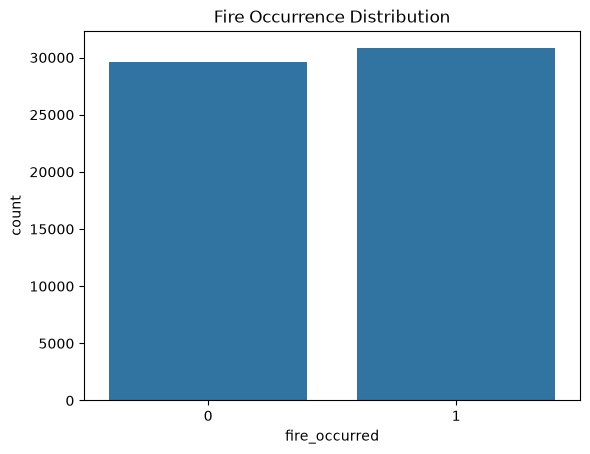

In [53]:
sns.countplot(data=df, x=TARGET)
plt.title("Fire Occurrence Distribution")
plt.show()

**My observation:** The target classes are nearly balanced, with fire observations accounting
for approximately 51% and no-fire observations approximately 49%.

Therefore, the Random Forest baseline does not require strong class-imbalance
correction for this dataset. However, this balanced distribution is specific
to the static baseline dataset and does not represent the prevalence of fire
events in the temporal dataset.

## 4. Correlation

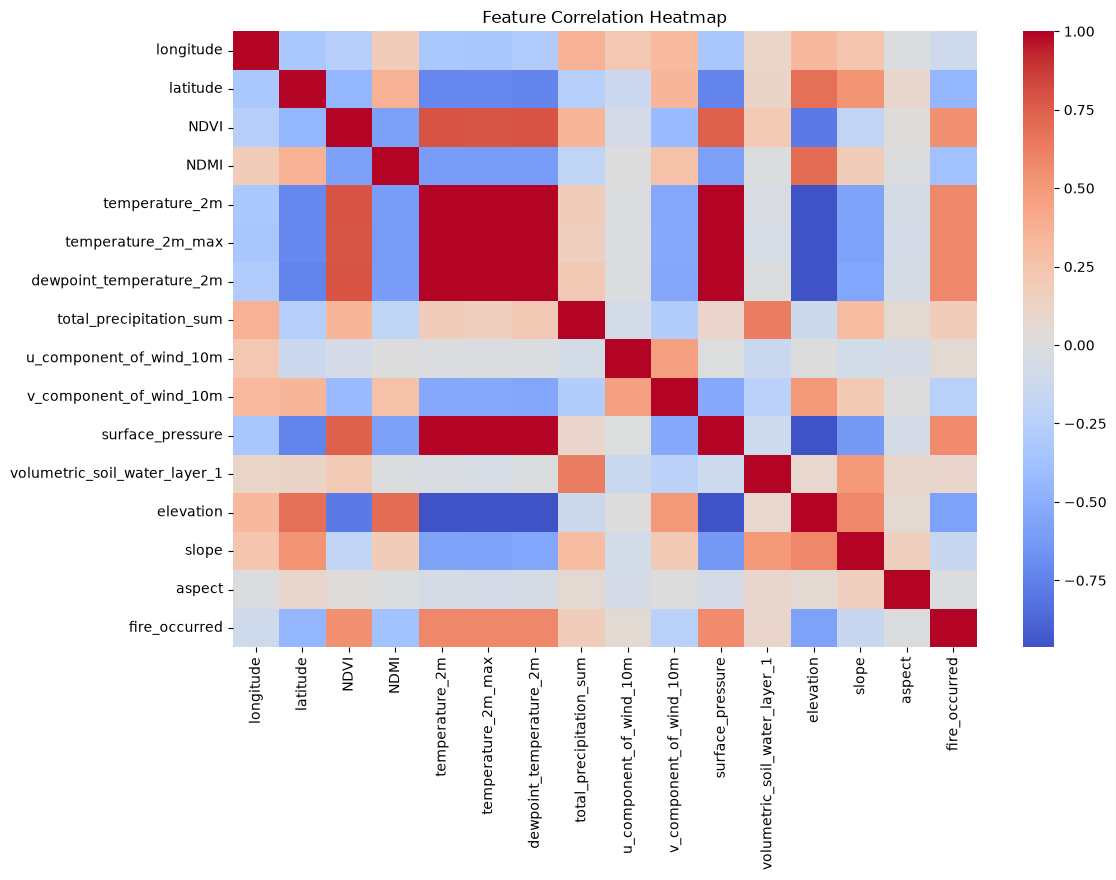

In [54]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

Correlation is not causation – this is only to understand the data.

**My observation:** _The correlation heatmap shows noticeable relationships among several
environmental variables, particularly between atmospheric variables.
These correlations are useful for understanding feature redundancy,
but correlation alone does not establish causal relationships or determine
model feature importance._

In [55]:
df["surface_pressure"].corr(df["temperature_2m"])

np.float64(0.992839429399001)

## 5. Feature engineering

In [56]:
# weather features look coarse (few unique values) – checking why
for c in ["temperature_2m", "surface_pressure", "total_precipitation_sum"]:
    print(c, df[c].nunique())
print("unique coordinates:", df[["longitude", "latitude"]].drop_duplicates().shape[0])

temperature_2m 559
surface_pressure 558
total_precipitation_sum 559
unique coordinates: 60434


Weather columns have only ~559 unique values for 60k cells (ERA5 is coarse), so neighbouring cells share the same weather. This matters for how we split the data later.

In [57]:
df = df.dropna().reset_index(drop=True)   # no missing values here, kept as a safety step

In [58]:
# wind speed from u and v components
df["wind_speed"] = np.sqrt(df["u_component_of_wind_10m"]**2 + df["v_component_of_wind_10m"]**2)

u = east-west component

v = north-south component

In [59]:
# dryness proxy: gap between air temperature and dewpoint
df["dewpoint_depression"] = df["temperature_2m"] - df["dewpoint_temperature_2m"]

Dewpoint depression was derived as the difference between air temperature
and dewpoint temperature. A larger dewpoint depression generally indicates
drier atmospheric conditions, which may contribute to fire-conducive
conditions.

In [60]:
# aspect is circular (0 and 360 are the same direction)
df["aspect_sin"] = np.sin(np.deg2rad(df["aspect"]))
df["aspect_cos"] = np.cos(np.deg2rad(df["aspect"]))

## 6. Select features and target
Longitude/latitude are **not** used as features, otherwise the Random Forest can just memorise locations.

In [61]:
FEATURES = ["NDVI", "NDMI", "temperature_2m", "temperature_2m_max", "dewpoint_temperature_2m",
            "total_precipitation_sum", "u_component_of_wind_10m", "v_component_of_wind_10m",
            "surface_pressure", "volumetric_soil_water_layer_1", "elevation", "slope",
            "wind_speed", "dewpoint_depression", "aspect_sin", "aspect_cos"]

In [62]:
X = df[FEATURES]
y = df[TARGET]
print(X.shape, y.shape)

(60434, 16) (60434,)


## 7. Spatial blocks

The study area is divided into approximately 0.25° spatial blocks so that
nearby grid cells are more likely to remain within the same validation group.
Whole spatial blocks are then held out during testing.

In [63]:
df["block"] = (df["longitude"] // 0.25).astype(int).astype(str) + "_" + (df["latitude"] // 0.25).astype(int).astype(str)
groups = df["block"]

In [64]:
groups.nunique()

104

## 8. Model and metric helpers

In [65]:
def make_rf():
    return RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_leaf=5,
                                  class_weight="balanced", n_jobs=-1, random_state=SEED)

In [66]:
def metrics(yt, yp, pr):
    return dict(accuracy=accuracy_score(yt, yp), precision=precision_score(yt, yp),
                recall=recall_score(yt, yp), f1=f1_score(yt, yp),
                roc_auc=roc_auc_score(yt, pr), pr_auc=average_precision_score(yt, pr))

results = {}

## 9. Random split (optimistic, for comparison only)
Neighbouring cells can land in both train and test, so this score is inflated.

In [67]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print("Train:", Xtr.shape[0], "Test:", Xte.shape[0])

Train: 48347 Test: 12087


In [68]:
rf = make_rf()
rf.fit(Xtr, ytr)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [69]:
rand_pred = rf.predict(Xte)
rand_proba = rf.predict_proba(Xte)[:, 1]

In [70]:
results["random_split"] = metrics(yte, rand_pred, rand_proba)
results["random_split"]

{'accuracy': 0.847025730123273,
 'precision': 0.8215191762423519,
 'recall': 0.8939590776226047,
 'f1': 0.8562096586048682,
 'roc_auc': 0.9292677434298724,
 'pr_auc': 0.9241323782704096}

## 10. Spatial-block split (main result)

In [71]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
tr, te = next(splitter.split(X, y, groups))
print("Train:", len(tr), "Test:", len(te))

Train: 50509 Test: 9925


In [72]:
rf_s = make_rf()
rf_s.fit(X.iloc[tr], y.iloc[tr])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [73]:
proba = rf_s.predict_proba(X.iloc[te])[:, 1]
pred = (proba >= 0.5).astype(int)

In [74]:
results["spatial_split"] = metrics(y.iloc[te], pred, proba)
results["spatial_split"]

{'accuracy': 0.7954659949622166,
 'precision': 0.7574322116955243,
 'recall': 0.8948282516402933,
 'f1': 0.8204175513092711,
 'roc_auc': 0.8790183636524459,
 'pr_auc': 0.8738286467953063}

In [75]:
print(classification_report(y.iloc[te], pred, target_names=["No fire", "Fire"]))

              precision    recall  f1-score   support

     No fire       0.86      0.69      0.76      4743
        Fire       0.76      0.89      0.82      5182

    accuracy                           0.80      9925
   macro avg       0.81      0.79      0.79      9925
weighted avg       0.80      0.80      0.79      9925



## 11. 5-fold spatial cross-validation

In [76]:
cv = []
for a_, b_ in GroupKFold(n_splits=5).split(X, y, groups):
    m = make_rf()
    m.fit(X.iloc[a_], y.iloc[a_])
    cv.append(metrics(y.iloc[b_], m.predict(X.iloc[b_]), m.predict_proba(X.iloc[b_])[:, 1]))
cv = pd.DataFrame(cv)
cv.round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.8580,0.8343,0.9263,0.8779,0.9162,0.9132
1,0.8136,0.7772,0.8741,0.8228,0.8953,0.8758
2,0.8573,0.8394,0.9123,0.8744,0.9241,0.9192
3,0.8187,0.7582,0.8555,0.8039,0.9023,0.8521
4,0.7954,0.7838,0.8400,0.8109,0.8802,0.8731


In [77]:
results["spatial_5fold_cv_mean"] = cv.mean().to_dict()
results["spatial_5fold_cv_std"] = cv.std().to_dict()

## 12. Results comparison

In [78]:
pd.DataFrame(results).T.round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
random_split,0.8470,0.8215,0.8940,0.8562,0.9293,0.9241
spatial_split,0.7955,0.7574,0.8948,0.8204,0.8790,0.8738
spatial_5fold_cv_mean,0.8286,0.7986,0.8817,0.8380,0.9036,0.8867
spatial_5fold_cv_std,0.0279,0.0362,0.0368,0.0355,0.0173,0.0286


#### Observation

The random split produces the highest ROC-AUC and PR-AUC because neighbouring
spatial cells can appear in both the training and test sets.

When entire spatial blocks are held out, performance decreases, with ROC-AUC
dropping from 0.929 to 0.879. This indicates that random splitting provides
an optimistic estimate of performance for spatial environmental data.

Across five spatial folds, the model achieves a mean ROC-AUC of 0.904 ± 0.017
and mean PR-AUC of 0.887 ± 0.029, indicating reasonably stable performance
across different geographic regions.

The spatial validation results are therefore treated as the main baseline
results.

## 13. Confusion matrix

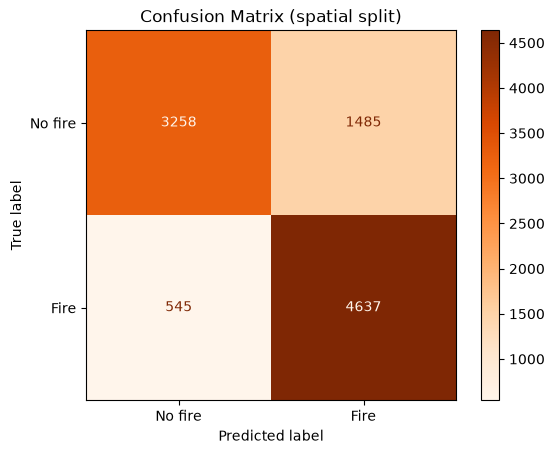

In [79]:
cm = confusion_matrix(y.iloc[te], pred)
ConfusionMatrixDisplay(cm, display_labels=["No fire", "Fire"]).plot(cmap="Oranges")
plt.title("Confusion Matrix (spatial split)")
plt.savefig("rf_confusion_matrix.png", dpi=150)
plt.show()

False negatives (actual fire, predicted no fire) matter most for an early-warning system.

## 14. ROC and Precision-Recall curves

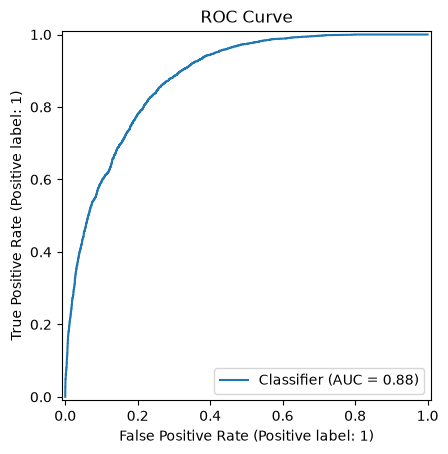

In [80]:
RocCurveDisplay.from_predictions(y.iloc[te], proba)
plt.title("ROC Curve")
plt.savefig("rf_roc_curve.png", dpi=150)
plt.show()

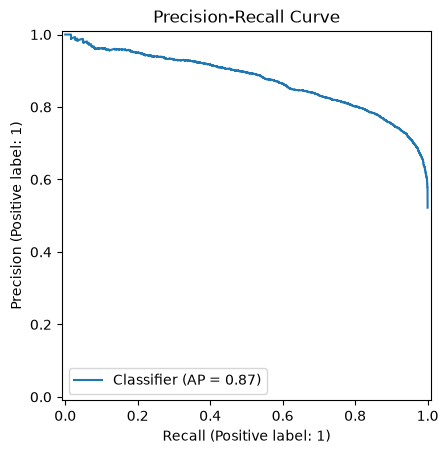

In [81]:
PrecisionRecallDisplay.from_predictions(y.iloc[te], proba)
plt.title("Precision-Recall Curve")
plt.savefig("rf_precision_recall_curve.png", dpi=150)
plt.show()

## 15. Feature importance

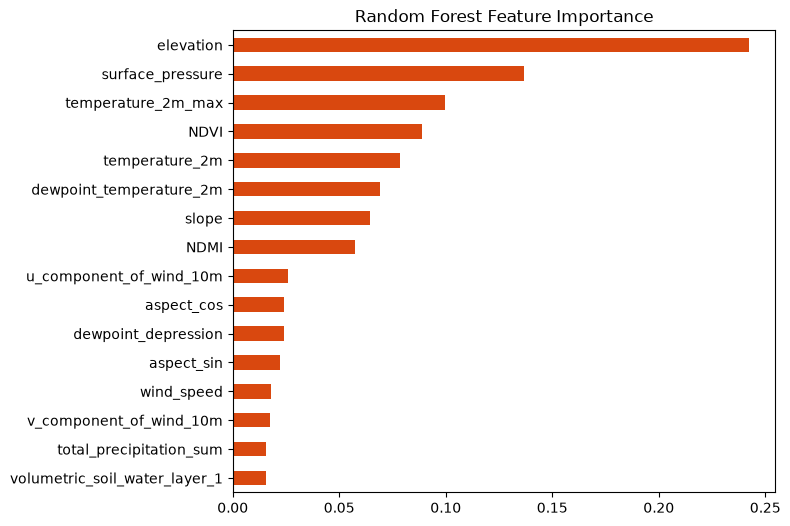

In [82]:
imp = pd.Series(rf_s.feature_importances_, index=FEATURES).sort_values()
imp.plot.barh(figsize=(7, 6), color="#d9480f")
plt.title("Random Forest Feature Importance")
plt.savefig("rf_feature_importance.png", dpi=150)
plt.show()

In [83]:
fi = imp.sort_values(ascending=False).reset_index()
fi.columns = ["feature", "importance"]
fi.to_csv("rf_feature_importance.csv", index=False)
fi

,feature,importance
0,elevation,0.242535
1,surface_pressure,0.136753
2,temperature_2m_max,0.099601
3,NDVI,0.088851
4,temperature_2m,0.078361
5,dewpoint_temperature_2m,0.069283
6,slope,0.064637
7,NDMI,0.057398
8,u_component_of_wind_10m,0.025917
9,aspect_cos,0.023948


**My observation:** _Elevation was the most influential feature according to the Random Forest's impurity-based feature importance._

## 16. Save model

In [84]:
os.makedirs("../models", exist_ok=True)
joblib.dump({"model": rf_s, "features": FEATURES}, "../models/random_forest_baseline.pkl")

['../models/random_forest_baseline.pkl']

## 17. Limitations
- Static features (not aligned to a fire date) → model learns *where* fires happen, not *when*.
- Classes are ~50/50 here vs ~0.9% positives in the time-series data, so PR-AUC is not directly comparable with the CNN-LSTM.
- No-fire recall is lower than fire recall (more false alarms); threshold tuning is future work.
- Weather variables have relatively coarse spatial variation compared with
  the 2 km grid, so neighbouring cells may share identical weather values.

- Impurity-based Random Forest feature importance can be affected by
  correlated features and should not be interpreted as causal importance.